# 02 — EDA & Feature Engineering

**Proyecto:** `ml_predict_income` · **Entrada:** `data/processed/enigh2024_ingreso_personas.parquet` (179,557 × 93)

---

## What this notebook is for

Understand the data, engineer the features, and **write down the candidate list** — nothing more.

**What it deliberately does NOT do:** no train/test split, no feature selection, no model fitting.
Those live in `03_feature_selection.ipynb`, which owns the split and does all selection on the training
partition only. Selecting features while looking at the whole dataset is the most common way to leak, and
splitting the work across two notebooks is how you avoid it.

| § | Output |
|---|---|
| 1 | Setup and chart palette |
| 2 | Target profiling: distribution, log-normality, inequality, by segment |
| 3 | **De-duplicate the encodings** — collapse the twin columns notebook 01 shipped on purpose |
| 4 | Missingness, by segment |
| 5 | Bivariate analysis vs income (weighted), with a signal-strength ranking |
| 6 | Redundancy: Spearman, Cramér's V, VIF |
| 7 | Feature engineering |
| 8 | **Elicitability audit** — the literal Spanish question behind every candidate |
| 9 | Save `enigh2024_features_v2.parquet` + `candidatas_v2.csv` |

## Decisions carried in from the planning discussion

- **Target treatment:** train on `log(ingreso_mensual)` with a quantile/L1 objective; the point estimate is
  the **conditional median**, back-transformed with `exp()` and **no smearing**. Measured on the worker
  segment with 15 features: MdAPE 30.0% vs 32.0% for a squared-loss fit in pesos.
- **Headline metrics:** median APE, share of predictions within ±20%, and interval coverage — not R².
- **Two models:** one for people who worked last month, one for those who did not. They behave differently
  enough that a single model is a compromise for both.
- **Form budget:** ~15 inputs per model.

Everything in this notebook is computed **weighted by `factor`** unless stated otherwise: unweighted
statistics describe the ENIGH sample, not Mexico.


---
## 1. Setup

Requirements: `pandas`, `numpy`, `matplotlib`, `scipy`, `pyarrow`.

```bash
pip install pandas numpy matplotlib scipy pyarrow
```


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROC_DIR / "enigh2024_ingreso_personas.parquet")
dicc = pd.read_csv(PROC_DIR / "diccionario_enigh2024_ingreso_personas.csv")
print(f"dataset: {len(df):,} filas × {df.shape[1]} columnas")
print(f"población representada: {df['factor'].sum():,.0f}")

dataset: 179,557 filas × 93 columnas
población representada: 77,144,542


In [2]:
# --------------------------------------------------------------- Paleta
# Slots categóricos en orden fijo (nunca se ciclan), rampa secuencial de un solo tono.
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
       "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
CMAP_SEQ = mpl.colors.LinearSegmentedColormap.from_list("azul", SEQ)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Segoe UI", "Helvetica", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "axes.labelcolor": INK2, "axes.edgecolor": AXIS,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png")
    return fig


def miles(x, _=None):
    return f"{x:,.0f}"


FMT_MILES = mpl.ticker.FuncFormatter(miles)

In [3]:
# --------------------------------------------------------------- Tipos de columna
# NO usar `df[c].dtype == object` para detectar texto. En pandas >= 3.0 las columnas de
# texto llegan con dtype `str` (respaldado por Arrow), no `object`: esa prueba devuelve
# False, la columna se trata como numérica y `pd.to_numeric(..., errors="coerce")` la
# convierte en NaN **sin lanzar error**. El resultado es un notebook que corre limpio y
# una variable que ya no aporta nada. Preguntar por lo numérico es estable en ambas versiones.
def es_numerica(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)


def es_categorica(s: pd.Series) -> bool:
    return not es_numerica(s)


print("pandas", pd.__version__, "| dtype de una columna de texto:", df["sexo"].dtype)
print("columnas numéricas:", sum(es_numerica(df[c]) for c in df.columns),
      "| categóricas:", sum(es_categorica(df[c]) for c in df.columns))

# --------------------------------------------------------------- Estadística ponderada
W = df["factor"].to_numpy()


def wmean(v, w=None):
    v = np.asarray(v, float); w = W if w is None else np.asarray(w, float)
    ok = ~np.isnan(v)
    return float(np.average(v[ok], weights=w[ok]))


def wquantile(v, q, w=None):
    v = np.asarray(v, float); w = W if w is None else np.asarray(w, float)
    ok = ~np.isnan(v); v, w = v[ok], w[ok]
    o = np.argsort(v); v, w = v[o], w[o]
    acum = np.cumsum(w) / w.sum()
    out = np.interp(np.atleast_1d(q), acum, v)
    return float(out[0]) if np.isscalar(q) else out


def wmedian(v, w=None):
    return wquantile(v, 0.5, w)


def wshare(mask, w=None):
    w = W if w is None else np.asarray(w, float)
    return float(np.average(np.asarray(mask, float), weights=w))


# Segmentos: el ruteo del producto es una sola pregunta, "¿trabajaste el mes pasado?"
df["segmento"] = np.where(df["tiene_trabajo_principal"] == 1, "Ocupados", "No ocupados")
OCU = df["segmento"] == "Ocupados"
print(df.groupby("segmento").agg(personas=("factor", "size"), poblacion=("factor", "sum")).round(0))

pandas 3.0.2 | dtype de una columna de texto: str
columnas numéricas: 62 | categóricas: 31
             personas  poblacion
segmento                        
No ocupados     40386   17358091
Ocupados       139171   59786451


---
## 2. The target

Three questions: what shape is it, is the log transform justified, and do the two segments really differ.


In [4]:
ing = df["ingreso_mensual"].to_numpy()
resumen = pd.Series({
    "media ponderada": wmean(ing),
    "mediana ponderada": wmedian(ing),
    "p10": wquantile(ing, .10), "p25": wquantile(ing, .25),
    "p75": wquantile(ing, .75), "p90": wquantile(ing, .90),
    "p99": wquantile(ing, .99), "p99.9": wquantile(ing, .999),
    "máximo": ing.max(),
    "asimetría (pesos)": float(pd.Series(ing).skew()),
    "asimetría (log)": float(np.log(pd.Series(ing).clip(lower=1)).skew()),
    "curtosis (pesos)": float(pd.Series(ing).kurt()),
    "curtosis (log)": float(np.log(pd.Series(ing).clip(lower=1)).kurt()),
})
display(resumen.round(2))
print("La media supera a la mediana en "
      f"{wmean(ing)/wmedian(ing):.2f}x — cola derecha larga, el caso de libro para modelar en logaritmo.")

media ponderada        10,677.64
mediana ponderada       7,907.61
p10                     1,614.13
p25                     3,913.04
p75                    12,961.95
p90                    20,869.56
p99                    55,543.00
p99.9                 138,395.55
máximo              5,791,304.34
asimetría (pesos)         149.85
asimetría (log)            -1.07
curtosis (pesos)       40,368.22
curtosis (log)              2.53
dtype: float64

La media supera a la mediana en 1.35x — cola derecha larga, el caso de libro para modelar en logaritmo.


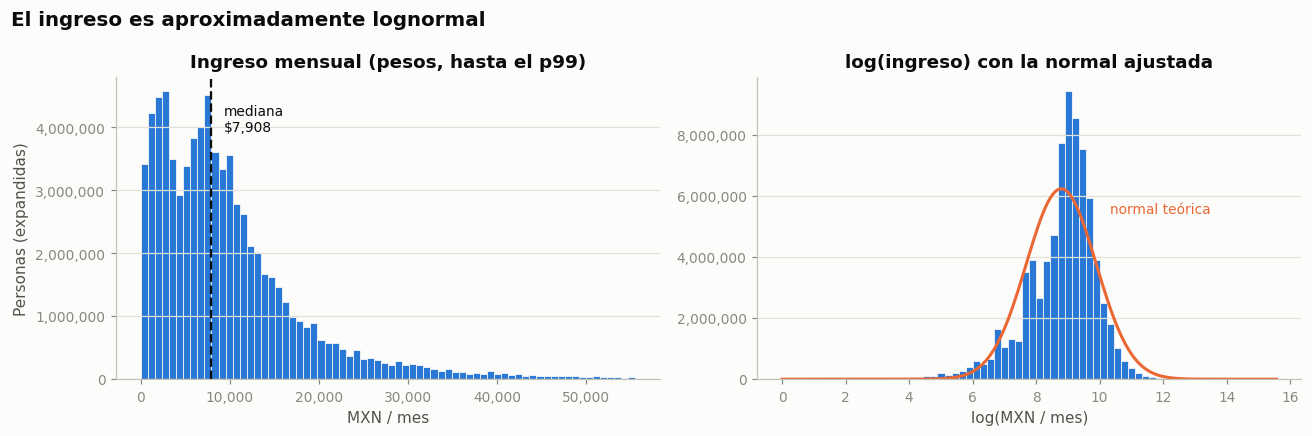

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

corte = wquantile(ing, .99)
ax = axes[0]
ax.hist(ing[ing <= corte], bins=70, weights=W[ing <= corte], color=SERIES[0], edgecolor=SURFACE, linewidth=0.5)
ax.axvline(wmedian(ing), color=INK, linewidth=1.5, linestyle="--")
ax.annotate(f"mediana\n${wmedian(ing):,.0f}", (wmedian(ing), ax.get_ylim()[1] * .82),
            xytext=(8, 0), textcoords="offset points", color=INK, fontsize=9)
ax.set_title("Ingreso mensual (pesos, hasta el p99)")
ax.set_xlabel("MXN / mes"); ax.set_ylabel("Personas (expandidas)")
ax.xaxis.set_major_formatter(FMT_MILES); ax.yaxis.set_major_formatter(FMT_MILES)

ax = axes[1]
lg = np.log(np.clip(ing, 1, None))
ax.hist(lg, bins=70, weights=W, color=SERIES[0], edgecolor=SURFACE, linewidth=0.5)
mu, sd = wmean(lg), np.sqrt(wmean((lg - wmean(lg)) ** 2))
xs = np.linspace(lg.min(), lg.max(), 200)
ax.plot(xs, W.sum() * (lg.max() - lg.min()) / 70 * np.exp(-((xs - mu) ** 2) / (2 * sd ** 2)) / (sd * np.sqrt(2 * np.pi)),
        color=SERIES[1], linewidth=2)
ax.set_title("log(ingreso) con la normal ajustada")
ax.set_xlabel("log(MXN / mes)"); ax.set_ylabel("")
ax.yaxis.set_major_formatter(FMT_MILES)
ax.annotate("normal teórica", (mu + 1.4 * sd, ax.get_ylim()[1] * .55), color=SERIES[1], fontsize=9)

fig.suptitle("El ingreso es aproximadamente lognormal", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "02_target_distribucion");

Gini ponderado del ingreso individual: 0.477
El decil más alto concentra 34.9% del ingreso total.


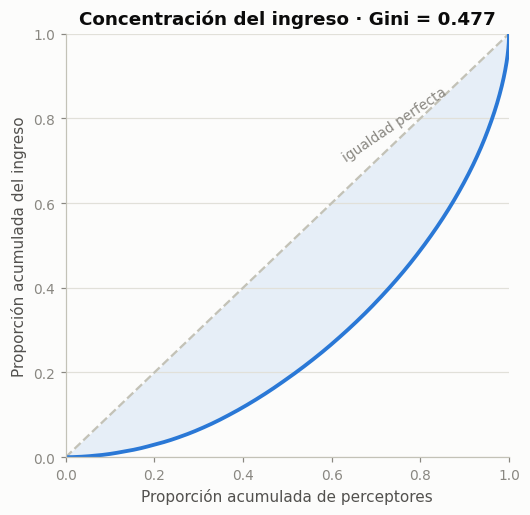

In [6]:
# Concentración: curva de Lorenz y Gini ponderado
o = np.argsort(ing)
v, w = ing[o], W[o]
pob = np.cumsum(w) / w.sum()
acum = np.cumsum(v * w) / (v * w).sum()
trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))   # numpy <2 usa np.trapz
gini = 1 - 2 * trapz(acum, pob)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.5, linestyle="--")
ax.plot(pob, acum, color=SERIES[0], linewidth=2.5)
ax.fill_between(pob, acum, pob, color=SERIES[0], alpha=.10, linewidth=0)
ax.set_title(f"Concentración del ingreso · Gini = {gini:.3f}")
ax.set_xlabel("Proporción acumulada de perceptores")
ax.set_ylabel("Proporción acumulada del ingreso")
ax.annotate("igualdad perfecta", (.62, .70), color=MUTED, fontsize=9, rotation=34)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
guardar(fig, "02_lorenz")
print(f"Gini ponderado del ingreso individual: {gini:.3f}")
print(f"El decil más alto concentra {1 - np.interp(.9, pob, acum):.1%} del ingreso total.")

,personas,población,mediana,media,p10,p90
segmento,,,,,,
No ocupados,40386,17358091,"3,587.00","6,818.00",901.00,"16,393.00"
Ocupados,139171,59786451,"8,852.00","11,798.00","2,299.00","21,913.00"


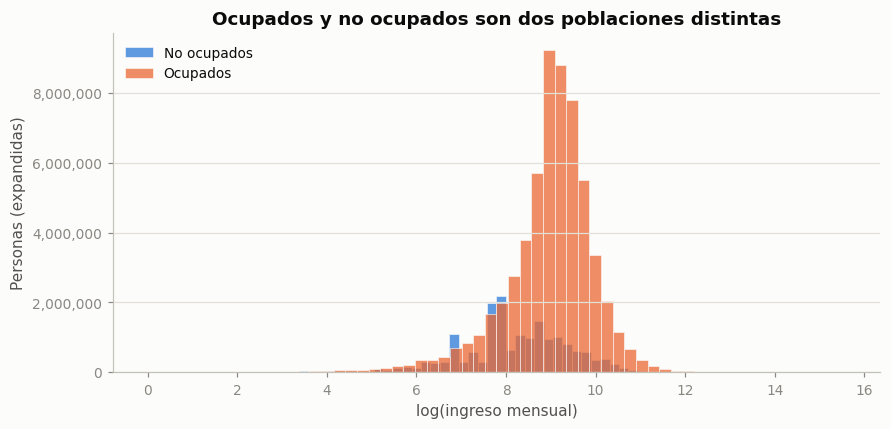

In [7]:
# Los dos segmentos del producto
fig, ax = plt.subplots(figsize=(9, 4))
for i, (nombre, sub) in enumerate(df.groupby("segmento")):
    l = np.log(sub["ingreso_mensual"].clip(lower=1))
    ax.hist(l, bins=60, weights=sub["factor"], color=SERIES[i], alpha=.75,
            edgecolor=SURFACE, linewidth=0.5, label=nombre)
ax.set_title("Ocupados y no ocupados son dos poblaciones distintas")
ax.set_xlabel("log(ingreso mensual)"); ax.set_ylabel("Personas (expandidas)")
ax.yaxis.set_major_formatter(FMT_MILES)
ax.legend(loc="upper left")
guardar(fig, "02_segmentos")

filas = []
for nombre, g in df.groupby("segmento"):
    v, p = g["ingreso_mensual"], g["factor"]
    filas.append({"segmento": nombre, "personas": len(g), "población": p.sum(),
                  "mediana": wmedian(v, p), "media": wmean(v, p),
                  "p10": wquantile(v, .10, p), "p90": wquantile(v, .90, p)})
display(pd.DataFrame(filas).set_index("segmento").round(0))

---
## 3. De-duplicate the encodings

Notebook 01 shipped several facts in more than one form on purpose, so the modelling stage could choose.
That choice happens **now**, before anything is ranked — if both twins stay in, importance gets split
between them and each looks mediocre.

Three groups of columns leave the candidate pool first:

| Group | Columns | Why |
|---|---|---|
| Target and its parts | `ingreso_mensual`, `log_ingreso_mensual`, `ingreso_mensual_laboral`, `ing_mens_*` | they *are* the target |
| Identifiers & design | `folioviv`, `foliohog`, `numren`, `factor`, `upm`, `est_dis` | not features; `factor`/`upm` are needed downstream and travel separately |
| Universe flags | `es_adulto`, `tiene_ingreso`, `outlier_ingreso` | constant or target-derived inside the universe |


In [8]:
TARGET = "ingreso_mensual"
FUGA = [c for c in df.columns if c.startswith("ing_mens_")] + \
       [TARGET, "log_ingreso_mensual", "ingreso_mensual_laboral"]
IDS = ["folioviv", "foliohog", "numren"]
DISENIO = ["factor", "upm", "est_dis"]
BANDERAS = ["es_adulto", "tiene_ingreso", "outlier_ingreso", "segmento"]

# Grupos de columnas redundantes: (se conserva, se descartan, motivo)
DUPLICADOS = [
    ("es_mujer", ["sexo"], "misma variable; la binaria evita una categoría"),
    ("anios_escolaridad", ["nivel_educativo"], "continua y ordenada; el nivel es un binning de ella"),
    ("cve_entidad", ["entidad", "entidad_nombre", "region"], "una sola codificación de estado; region es un binning"),
    ("cve_municipio", ["municipio_nombre"], "código y nombre son la misma variable"),
    ("tamanio_localidad", ["es_rural"], "ordinal de 4 niveles contiene a la binaria"),
    ("situacion_conyugal", ["vive_en_pareja"], "la categórica contiene a la binaria"),
    ("tiene_trabajo_principal", ["trabajo_mes_pasado", "ocupado"], "las tres son la misma condición"),
    ("sinco_grupo", ["sinco"], "477 códigos no son preguntables; el grupo de 1 dígito rinde igual"),
    ("scian_sector", ["scian"], "mismo argumento en la actividad económica"),
    ("integrantes_hogar", ["residentes_vivienda"], "casi idénticas; se conserva la del hogar, preguntable"),
]
DESCARTADAS_DUP = [c for _, ds, _ in DUPLICADOS for c in ds]

tabla_dup = pd.DataFrame(
    [{"se conserva": k, "se descarta": ", ".join(ds), "motivo": m} for k, ds, m in DUPLICADOS])
display(tabla_dup)

# Correlación empírica dentro de cada par numérico, como verificación
for keep, drops, _ in DUPLICADOS:
    for d in drops:
        if es_numerica(df[keep]) and es_numerica(df[d]):
            r = df[[keep, d]].astype(float).corr().iloc[0, 1]
            print(f"  corr({keep}, {d}) = {r:.3f}")

,se conserva,se descarta,motivo
0,es_mujer,sexo,misma variable; la binaria evita una categoría
1,anios_escolaridad,nivel_educativo,continua y ordenada; el nivel es un binning de...
2,cve_entidad,"entidad, entidad_nombre, region",una sola codificación de estado; region es un ...
3,cve_municipio,municipio_nombre,código y nombre son la misma variable
4,tamanio_localidad,es_rural,ordinal de 4 niveles contiene a la binaria
5,situacion_conyugal,vive_en_pareja,la categórica contiene a la binaria
6,tiene_trabajo_principal,"trabajo_mes_pasado, ocupado",las tres son la misma condición
7,sinco_grupo,sinco,477 códigos no son preguntables; el grupo de 1...
8,scian_sector,scian,mismo argumento en la actividad económica
9,integrantes_hogar,residentes_vivienda,"casi idénticas; se conserva la del hogar, preg..."


  corr(tiene_trabajo_principal, trabajo_mes_pasado) = 0.988
  corr(tiene_trabajo_principal, ocupado) = 0.988
  corr(integrantes_hogar, residentes_vivienda) = 0.958


In [9]:
CANDIDATAS = [c for c in df.columns
              if c not in FUGA + IDS + DISENIO + BANDERAS + DESCARTADAS_DUP]
NUMERICAS = [c for c in CANDIDATAS if es_numerica(df[c])]
CATEGORICAS = [c for c in CANDIDATAS if es_categorica(df[c])]

print(f"93 columnas originales")
print(f"  −{len(FUGA)} target y componentes")
print(f"  −{len(IDS) + len(DISENIO)} identificadores y diseño muestral")
print(f"  −{len(BANDERAS) - 1} banderas de universo")
print(f"  −{len(DESCARTADAS_DUP)} codificaciones duplicadas")
print(f"  = {len(CANDIDATAS)} candidatas reales  ({len(NUMERICAS)} numéricas, {len(CATEGORICAS)} categóricas)")

93 columnas originales
  −9 target y componentes
  −6 identificadores y diseño muestral
  −3 banderas de universo
  −13 codificaciones duplicadas
  = 62 candidatas reales  (44 numéricas, 18 categóricas)


---
## 4. Missingness, by segment

Most of the gaps are **structural**, not defects: job variables are empty for people who do not work,
`hijos_sobrevivientes` is only asked of women, `tiene_socios` only of the self-employed. A column that is
95% empty in one segment and complete in the other is not a bad column — it is a column that belongs to
one of the two models.


,todos,ocupados,no_ocupados
tiene_socios,83.80,79.10,100.00
actividad_no_ocupado,77.50,100.00,0.00
contrato_indefinido,71.20,62.80,100.00
hijos_sobrevivientes,62.90,68.70,42.80
tiene_contrato_escrito,41.80,24.90,100.00
tam_empresa,24.20,2.20,100.00
empleo_formal,22.50,0.00,100.00
horas_trabajadas,22.50,0.00,100.00
sin_prestaciones,22.50,0.00,100.00
n_prestaciones,22.50,0.00,100.00


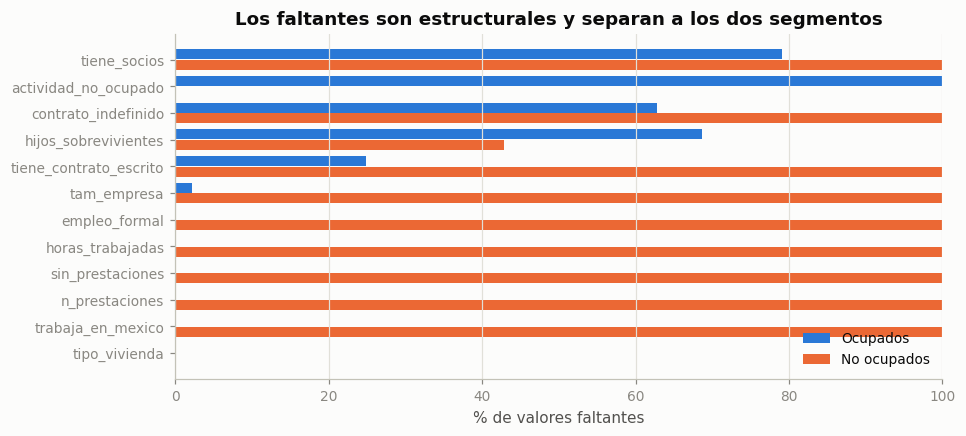

In [10]:
falt = pd.DataFrame({
    "todos": df[CANDIDATAS].isna().mean() * 100,
    "ocupados": df.loc[OCU, CANDIDATAS].isna().mean() * 100,
    "no_ocupados": df.loc[~OCU, CANDIDATAS].isna().mean() * 100,
}).round(1)
falt = falt[falt["todos"] > 0].sort_values("todos", ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, .34 * len(falt))))
yy = np.arange(len(falt))
ax.barh(yy - .2, falt["ocupados"], height=.38, color=SERIES[0], label="Ocupados")
ax.barh(yy + .2, falt["no_ocupados"], height=.38, color=SERIES[1], label="No ocupados")
ax.set_yticks(yy); ax.set_yticklabels(falt.index)
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("% de valores faltantes")
ax.set_title("Los faltantes son estructurales y separan a los dos segmentos")
ax.legend(loc="lower right")
guardar(fig, "02_faltantes")
display(falt)

---
## 5. Bivariate analysis

Everything here is weighted. For each candidate we want two things: the **shape** of the relationship
(does income rise linearly with schooling? does it peak and fall with age?) and a comparable
**signal-strength** number so the candidates can be ranked.

The measure used is the **weighted correlation ratio η²** — the share of the variance of `log(income)`
explained by the variable on its own. It works identically for a categorical variable and for a binned
numeric one, so a single column ranks the whole pool. It is univariate by construction: it ignores
redundancy between candidates, which is exactly what §6 is for.


In [11]:
LOG_ING = np.log(df[TARGET].clip(lower=1))


def eta2_ponderado(grupos, y=LOG_ING, w=None):
    """Razón de correlación ponderada: varianza explicada por la variable, entre 0 y 1."""
    w = df["factor"].to_numpy() if w is None else np.asarray(w, float)
    y = np.asarray(y, float)
    g = pd.Series(grupos).astype(object).fillna("__NA__").to_numpy()
    ok = ~np.isnan(y)
    y, w, g = y[ok], w[ok], g[ok]
    codigos, _ = pd.factorize(g)
    media = np.average(y, weights=w)
    peso_grupo = np.bincount(codigos, weights=w)
    media_grupo = np.bincount(codigos, weights=w * y) / np.maximum(peso_grupo, 1e-12)
    entre = (peso_grupo * (media_grupo - media) ** 2).sum()
    total = (w * (y - media) ** 2).sum()
    return float(entre / total) if total > 0 else np.nan


def binificar(serie, k=12):
    """Deciles (o k-iles) de una numérica, para medir señal sin suponer linealidad.

    Las categóricas se devuelven tal cual. Las binarias y las de pocos valores distintos
    también: pasarlas por qcut las colapsa a un solo bin y su η² saldría 0 por construcción."""
    if es_categorica(serie):
        return serie.astype(str)
    if serie.nunique(dropna=True) <= k:
        return serie.astype(str)
    binned = pd.qcut(serie, k, duplicates="drop")
    if binned.nunique(dropna=True) < 2:
        return serie.astype(str)
    return binned.astype(str)


senial = []
for c in CANDIDATAS:
    grupos = binificar(df[c])
    senial.append({
        "variable": c,
        "tipo": "categórica" if es_categorica(df[c]) else "numérica",
        "n_niveles": int(df[c].nunique()),
        "eta2_global": eta2_ponderado(grupos),
        "eta2_ocupados": eta2_ponderado(grupos[OCU], LOG_ING[OCU], df.loc[OCU, "factor"]),
        "eta2_no_ocup": eta2_ponderado(grupos[~OCU], LOG_ING[~OCU], df.loc[~OCU, "factor"]),
        "pct_nulos": round(df[c].isna().mean() * 100, 1),
    })
senial = pd.DataFrame(senial).sort_values("eta2_global", ascending=False).reset_index(drop=True)
senial.head(30).round(4)

,variable,tipo,n_niveles,eta2_global,eta2_ocupados,eta2_no_ocup,pct_nulos
0,sinco_grupo,categórica,11,0.22,0.21,0.00,0.00
1,n_prestaciones,numérica,20,0.22,0.20,0.00,22.50
2,tiene_contrato_escrito,numérica,2,0.21,0.19,0.00,41.80
3,empleo_formal,numérica,2,0.20,0.18,0.00,22.50
4,horas_trabajadas,numérica,138,0.20,0.17,0.00,22.50
5,tam_empresa,numérica,11,0.19,0.19,0.00,24.20
6,cotiza_seguridad_social,numérica,2,0.19,0.17,0.19,0.00
7,scian_sector,categórica,22,0.19,0.16,0.00,0.00
8,contrato_indefinido,numérica,2,0.18,0.19,0.00,71.20
9,clase_empleador,categórica,5,0.18,0.17,0.00,0.00


Ojo: η² es univariado. Una variable alta puede ser redundante con otra más alta (§6),
y una baja puede aportar mucho en presencia del resto. Es un filtro, no un veredicto.


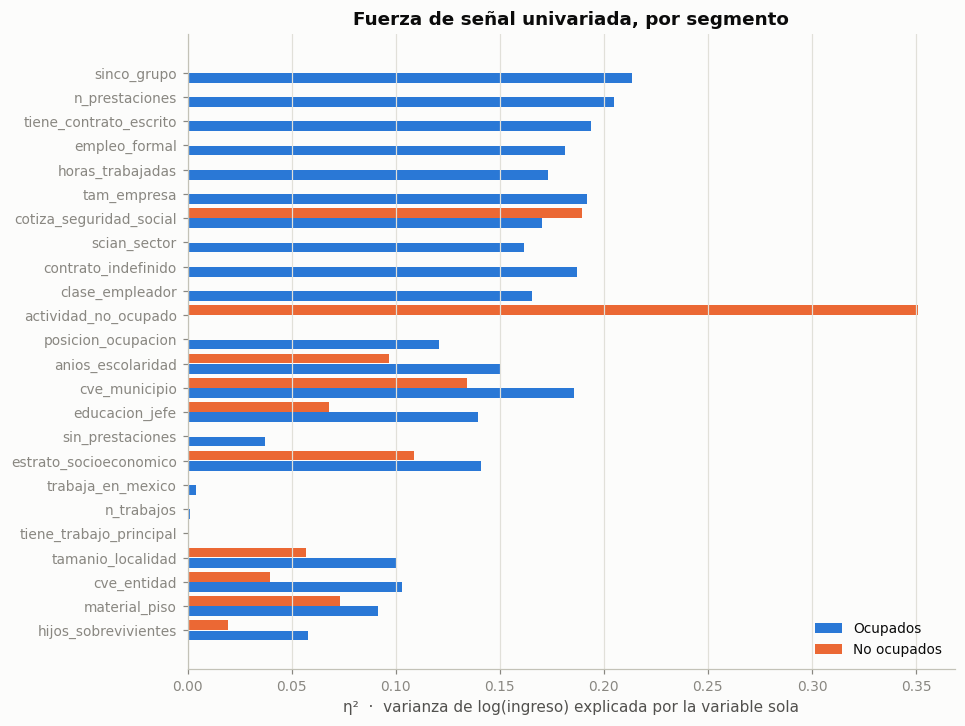

In [12]:
top = senial.head(24).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7.5))
yy = np.arange(len(top))
ax.barh(yy - .21, top["eta2_ocupados"], height=.40, color=SERIES[0], label="Ocupados")
ax.barh(yy + .21, top["eta2_no_ocup"], height=.40, color=SERIES[1], label="No ocupados")
ax.set_yticks(yy); ax.set_yticklabels(top["variable"])
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("η²  ·  varianza de log(ingreso) explicada por la variable sola")
ax.set_title("Fuerza de señal univariada, por segmento")
ax.legend(loc="lower right")
guardar(fig, "02_senal_univariada")
print("Ojo: η² es univariado. Una variable alta puede ser redundante con otra más alta (§6),\n"
      "y una baja puede aportar mucho en presencia del resto. Es un filtro, no un veredicto.")

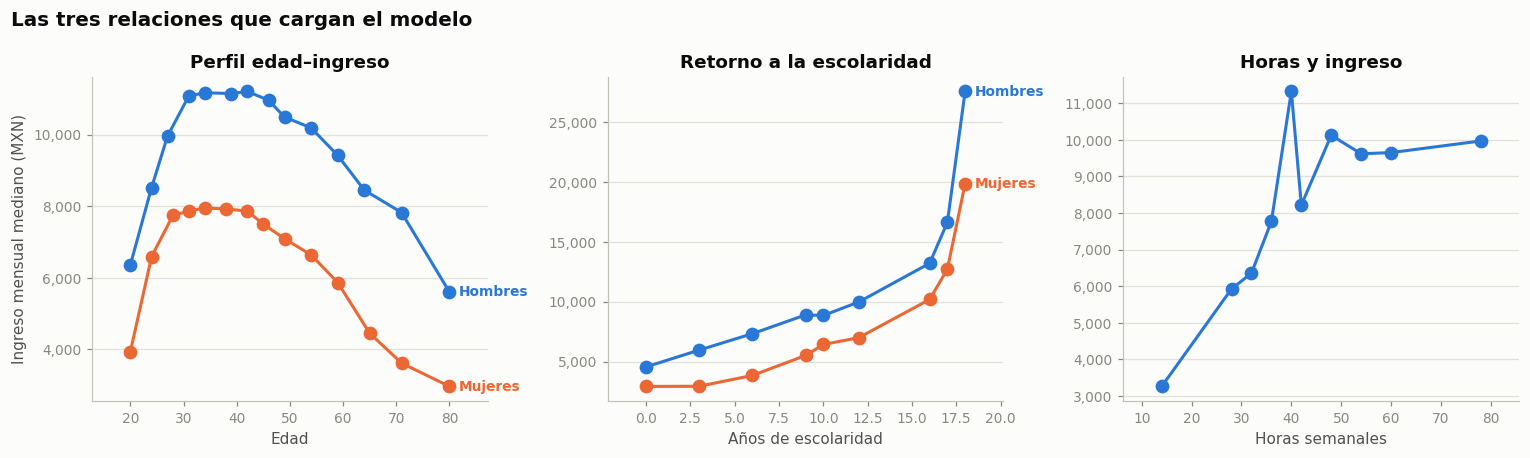

In [13]:
# --------- Forma de las relaciones clave: edad, escolaridad, horas, ocupación
def perfil_numerico(ax, col, titulo, xlabel, k=14, bins=None, por_sexo=True):
    """Mediana ponderada del ingreso por tramo. `bins` explícitos cuando la variable
    tiene masas puntuales (40 y 48 horas), donde los cuantiles producen tramos absurdos."""
    d = df[[col, TARGET, "factor", "es_mujer"]].dropna(subset=[col])
    d["bin"] = pd.cut(d[col], bins) if bins is not None else pd.qcut(d[col], k, duplicates="drop")
    series = ([("Hombres", d[d.es_mujer == 0]), ("Mujeres", d[d.es_mujer == 1])]
              if por_sexo else [(None, d)])
    for i, (etiqueta, sub) in enumerate(series):
        g = sub.groupby("bin", observed=True)
        x = g[col].median().to_numpy()
        y = np.array([wmedian(s[TARGET], s["factor"]) for _, s in g])
        ax.plot(x, y, color=SERIES[i], marker="o")
        if etiqueta:   # etiqueta directa en el extremo, en vez de caja de leyenda
            ax.annotate(etiqueta, (x[-1], y[-1]), xytext=(6, 0), textcoords="offset points",
                        color=SERIES[i], fontsize=9, va="center", fontweight="semibold")
    ax.set_title(titulo); ax.set_xlabel(xlabel)
    ax.yaxis.set_major_formatter(FMT_MILES)
    ax.margins(x=.12)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
perfil_numerico(axes[0], "edad", "Perfil edad–ingreso", "Edad")
axes[0].set_ylabel("Ingreso mensual mediano (MXN)")
perfil_numerico(axes[1], "anios_escolaridad", "Retorno a la escolaridad", "Años de escolaridad")
perfil_numerico(axes[2], "horas_trabajadas", "Horas y ingreso", "Horas semanales",
                bins=[0, 20, 30, 34, 39, 40, 44, 48, 56, 70, 168], por_sexo=False)
fig.suptitle("Las tres relaciones que cargan el modelo", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "02_perfiles_numericos");

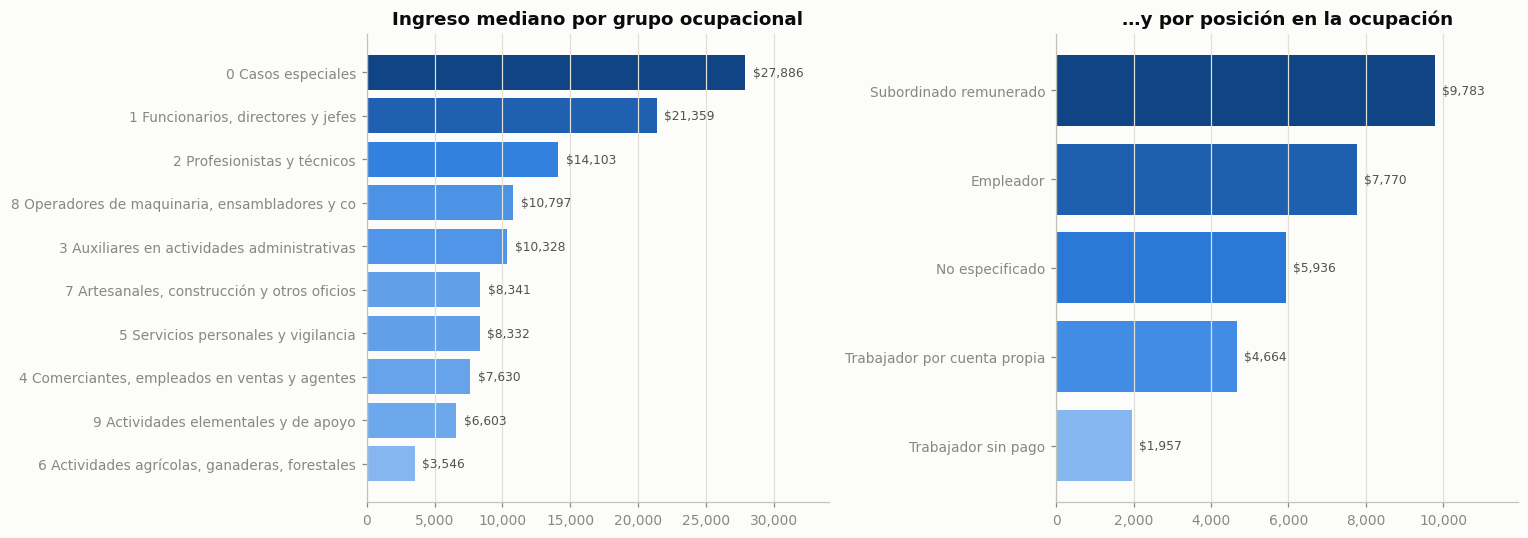

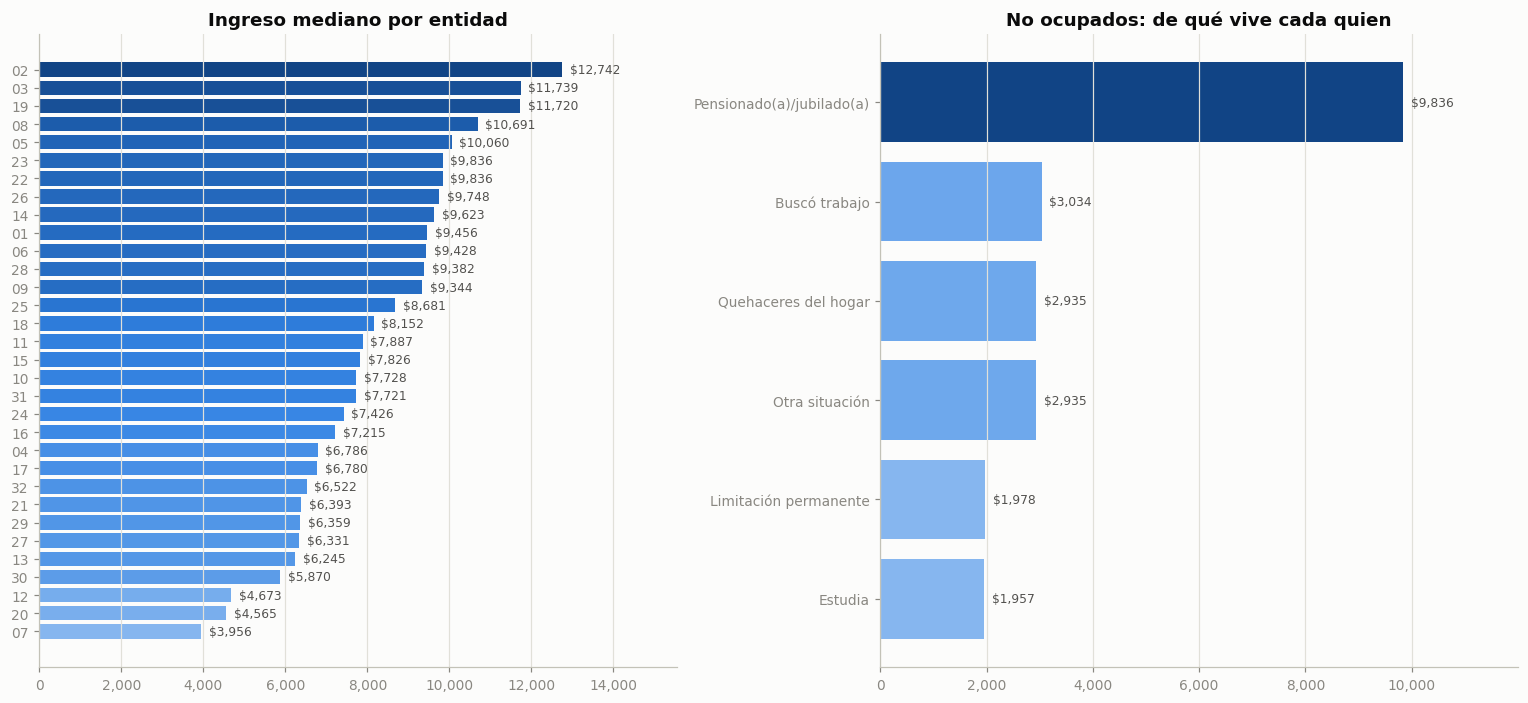

In [14]:
def barras_categoria(ax, col, titulo, n=None, segmento=None):
    d = df if segmento is None else df[df["segmento"] == segmento]
    d = d[[col, TARGET, "factor"]].dropna(subset=[col])
    filas = [{"cat": k, "mediana": wmedian(g[TARGET], g["factor"]), "pob": g["factor"].sum()}
             for k, g in d.groupby(col)]
    t = pd.DataFrame(filas).sort_values("mediana")
    if n:
        t = t.tail(n)
    col_norm = (t["mediana"] - t["mediana"].min()) / (t["mediana"].max() - t["mediana"].min() + 1e-9)
    ax.barh(np.arange(len(t)), t["mediana"], color=CMAP_SEQ(.25 + .65 * col_norm))
    ax.set_yticks(np.arange(len(t)))
    ax.set_yticklabels([c[:46] for c in t["cat"]])
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(FMT_MILES)
    ax.set_title(titulo)
    for i, v in enumerate(t["mediana"]):
        ax.annotate(f"${v:,.0f}", (v, i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK2)
    ax.set_xlim(0, t["mediana"].max() * 1.22)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
barras_categoria(axes[0], "sinco_grupo", "Ingreso mediano por grupo ocupacional", segmento="Ocupados")
barras_categoria(axes[1], "posicion_ocupacion", "…y por posición en la ocupación", segmento="Ocupados")
fig.tight_layout()
guardar(fig, "02_ocupacion")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
barras_categoria(axes[0], "cve_entidad", "Ingreso mediano por entidad", n=32)
barras_categoria(axes[1], "actividad_no_ocupado", "No ocupados: de qué vive cada quien",
                 segmento="No ocupados")
fig.tight_layout()
guardar(fig, "02_geografia_y_no_ocupados");

---
## 6. Redundancy

η² ranks each candidate in isolation. This section asks the opposite question: how much of each candidate
is already contained in the others. Three views — Spearman for numeric pairs (monotone, robust to the
skew), Cramér's V for categorical pairs, and VIF for multicollinearity across the numeric block.


Pares con |ρ| > 0.6 — revisar antes de la selección:


rho
n_dificultades          tiene_discapacidad      1.00
n_trabajos              tiene_trabajo_principal 0.90
empleo_formal           n_prestaciones          0.88
                        tiene_contrato_escrito  0.76
n_prestaciones          tiene_contrato_escrito  0.76
integrantes_hogar       hacinamiento            0.72
num_cuartos             num_dormitorios         0.71
sin_prestaciones        tiene_contrato_escrito  0.70
ocupados_hogar          perceptores_hogar       0.69
n_prestaciones          tam_empresa             0.69
adultos_mayores_hogar   edad_jefe               0.68
integrantes_hogar       perceptores_hogar       0.68
empleo_formal           tam_empresa             0.68
tam_empresa             tiene_contrato_escrito  0.61
cotiza_seguridad_social empleo_formal           0.61
integrantes_hogar       menores_hogar           0.60

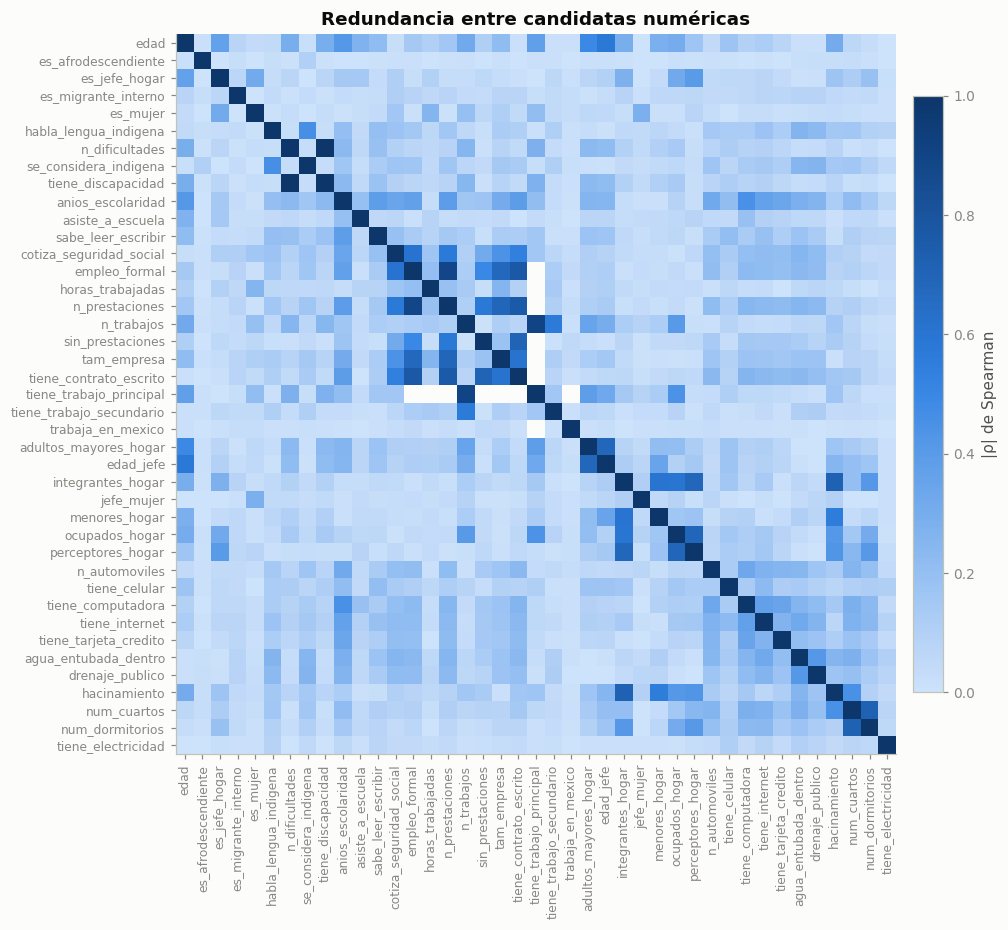

In [15]:
from scipy.stats import chi2_contingency

num_ok = [c for c in NUMERICAS if df[c].notna().mean() > .5]
rho = df[num_ok].astype(float).corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(rho.abs(), cmap=CMAP_SEQ, vmin=0, vmax=1)
ax.set_xticks(range(len(num_ok))); ax.set_xticklabels(num_ok, rotation=90, fontsize=8)
ax.set_yticks(range(len(num_ok))); ax.set_yticklabels(num_ok, fontsize=8)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
cb.set_label("|ρ| de Spearman", color=INK2)
ax.set_title("Redundancia entre candidatas numéricas")
guardar(fig, "02_redundancia")

pares = (rho.abs().where(np.triu(np.ones(rho.shape), 1).astype(bool))
         .stack().sort_values(ascending=False))
print("Pares con |ρ| > 0.6 — revisar antes de la selección:")
display(pares[pares > .6].round(3).to_frame("rho"))

In [16]:
def cramers_v(a, b, w):
    t = pd.crosstab(a.fillna("__NA__"), b.fillna("__NA__"), values=w, aggfunc="sum").fillna(0)
    if t.shape[0] < 2 or t.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(t, correction=False)[0]
    n = t.to_numpy().sum()
    return float(np.sqrt((chi2 / n) / (min(t.shape) - 1)))


cat_ok = [c for c in CATEGORICAS if df[c].nunique() <= 40]
V = pd.DataFrame(index=cat_ok, columns=cat_ok, dtype=float)
for i, a in enumerate(cat_ok):
    for b in cat_ok[i:]:
        v = 1.0 if a == b else cramers_v(df[a], df[b], df["factor"])
        V.loc[a, b] = V.loc[b, a] = v
pares_v = (V.where(np.triu(np.ones(V.shape), 1).astype(bool)).stack().sort_values(ascending=False))
print("Pares categóricos con V de Cramér > 0.5:")
display(pares_v[pares_v > .5].round(3).to_frame("V"))

Pares categóricos con V de Cramér > 0.5:


,,V
scian_sector,sinco_grupo,0.59
clase_empleador,scian_sector,0.55
posicion_ocupacion,sinco_grupo,0.50


In [17]:
# VIF sin dependencias extra: 1 / (1 - R² de regresar cada variable contra las demás)
Xv = df[num_ok].astype(float)
Xv = Xv.fillna(Xv.median())
Xv = Xv.loc[:, Xv.std() > 0]
Z = ((Xv - Xv.mean()) / Xv.std()).to_numpy()
Z = np.column_stack([np.ones(len(Z)), Z])
nombres = list(Xv.columns)

vif = {}
for j, nombre in enumerate(nombres, start=1):
    otras = np.delete(Z, j, axis=1)
    coef, *_ = np.linalg.lstsq(otras, Z[:, j], rcond=None)
    resid = Z[:, j] - otras @ coef
    r2 = 1 - resid.var() / Z[:, j].var()
    vif[nombre] = 1 / max(1 - r2, 1e-9)
vif = pd.Series(vif).sort_values(ascending=False)

print("VIF > 5 indica colinealidad relevante para un modelo lineal.\n"
      "Los árboles la toleran, pero reparte la importancia entre las colineales:")
display(vif[vif > 3].round(2).to_frame("VIF"))

VIF > 5 indica colinealidad relevante para un modelo lineal.
Los árboles la toleran, pero reparte la importancia entre las colineales:


,VIF
n_trabajos,"1,000,000,000.00"
tiene_trabajo_principal,"1,000,000,000.00"
tiene_trabajo_secundario,"1,000,000,000.00"
integrantes_hogar,6.98
empleo_formal,5.51
n_prestaciones,4.73
tiene_contrato_escrito,3.88
ocupados_hogar,3.81
perceptores_hogar,3.76
edad,3.35


---
## 7. Feature engineering

Six new columns. Each exists for a stated reason, and three of them exist specifically to **replace several
raw columns with one question a person can answer**.

| New feature | Replaces / adds | Why |
|---|---|---|
| `experiencia_potencial` | — | `edad − anios_escolaridad − 6`, the Mincer term. Separates "45 and started working at 15" from "45 and started at 24", which age alone cannot. |
| `jornada` | reads `horas_trabajadas` | part-time / full-time / extended. Hours is the strongest single predictor, but the raw number is noisy at the edges; the banded version is also easier to ask. |
| `formalidad` | `cotiza_seguridad_social` + `n_prestaciones` + `empleo_formal` | three correlated columns collapse into one 3-level question: *"¿tu trabajo te da IMSS/ISSSTE y prestaciones?"* |
| `tam_empresa_grupo` | `tam_empresa` | micro / small / medium / large, instead of an 11-point scale nobody can place themselves on |
| `sector_agrupado` | `scian_sector` | 23 SCIAN sectors → 8 recognizable ones |
| `razon_dependencia` | `menores_hogar`, `adultos_mayores_hogar`, `integrantes_hogar` | dependents per member; a ratio travels better across household sizes than three counts |

`ingreso_por_hora` is also computed — **strictly for diagnostics in this notebook**. It is derived from the
target and must never reach a feature list. It is excluded from the saved candidate set and asserted against
at the end.


In [18]:
fe = pd.DataFrame(index=df.index)

# 1. Experiencia potencial (término de Mincer)
fe["experiencia_potencial"] = (df["edad"] - df["anios_escolaridad"].fillna(0) - 6).clip(lower=0)

# 2. Jornada laboral
fe["jornada"] = pd.cut(df["horas_trabajadas"],
                       bins=[0, 34.9, 48, 1e9],
                       labels=["1 Parcial (<35h)", "2 Completa (35-48h)", "3 Extendida (>48h)"]
                       ).astype(object)
fe.loc[df["tiene_trabajo_principal"] == 0, "jornada"] = "0 No trabaja"

# 3. Formalidad, en tres niveles preguntables
cotiza = df["cotiza_seguridad_social"].fillna(0).astype(float)
formal = df["empleo_formal"].fillna(0).astype(float)
prest = df["n_prestaciones"].fillna(0).astype(float)
fe["formalidad"] = np.select(
    [df["tiene_trabajo_principal"] == 0,
     (cotiza == 1) | (formal == 1),
     prest > 0],
    ["0 No trabaja", "3 Formal (con seguridad social)", "2 Informal con algunas prestaciones"],
    default="1 Informal sin prestaciones")

# 4. Tamaño de empresa agrupado
fe["tam_empresa_grupo"] = pd.cut(df["tam_empresa"].astype(float),
                                 bins=[0, 2, 7, 9, 11],
                                 labels=["1 Micro (1-5)", "2 Pequeña (6-50)",
                                         "3 Mediana (51-250)", "4 Grande (251+)"]).astype(object)
fe["tam_empresa_grupo"] = fe["tam_empresa_grupo"].fillna("0 No aplica / no sabe")

# 5. Sector agrupado
SECTOR_8 = {
    "11 Agricultura, cría, forestal, pesca": "1 Agropecuario",
    "21 Minería": "2 Industria", "22 Electricidad, agua y gas": "2 Industria",
    "31-33 Industrias manufactureras": "2 Industria",
    "23 Construcción": "3 Construcción",
    "43 Comercio al por mayor": "4 Comercio", "46 Comercio al por menor": "4 Comercio",
    "48-49 Transportes y almacenamiento": "5 Transporte y logística",
    "51 Información en medios masivos": "6 Servicios profesionales y financieros",
    "52 Servicios financieros y de seguros": "6 Servicios profesionales y financieros",
    "53 Servicios inmobiliarios y de alquiler": "6 Servicios profesionales y financieros",
    "54 Servicios profesionales, científicos y técnicos": "6 Servicios profesionales y financieros",
    "55 Corporativos": "6 Servicios profesionales y financieros",
    "56 Apoyo a negocios y manejo de residuos": "6 Servicios profesionales y financieros",
    "61 Servicios educativos": "7 Educación, salud y gobierno",
    "62 Servicios de salud y asistencia social": "7 Educación, salud y gobierno",
    "93 Gobierno y organismos internacionales": "7 Educación, salud y gobierno",
    "71 Esparcimiento y recreación": "8 Otros servicios",
    "72 Alojamiento temporal y alimentos": "8 Otros servicios",
    "81 Otros servicios excepto gobierno": "8 Otros servicios",
}
_fallback = pd.Series(np.where(df["tiene_trabajo_principal"] == 0, "0 No trabaja", "9 No especificado"),
                      index=df.index)
fe["sector_agrupado"] = df["scian_sector"].map(SECTOR_8).fillna(_fallback)

# 6. Razón de dependencia del hogar
fe["razon_dependencia"] = ((df["menores_hogar"].fillna(0) + df["adultos_mayores_hogar"].fillna(0))
                           / df["integrantes_hogar"].replace(0, np.nan)).round(3)

# Sólo diagnóstico — derivado del target, NUNCA es feature
diag_ingreso_hora = (df[TARGET] / (df["horas_trabajadas"] * 4.33)).replace([np.inf, -np.inf], np.nan)

NUEVAS = list(fe.columns)
for c in NUEVAS:
    df[c] = fe[c]
print(f"{len(NUEVAS)} variables nuevas: {NUEVAS}")
display(df[NUEVAS].head())

6 variables nuevas: ['experiencia_potencial', 'jornada', 'formalidad', 'tam_empresa_grupo', 'sector_agrupado', 'razon_dependencia']


,experiencia_potencial,jornada,formalidad,tam_empresa_grupo,sector_agrupado,razon_dependencia
0,17.00,2 Completa (35-48h),3 Formal (con seguridad social),0 No aplica / no sabe,2 Industria,0.50
1,6.00,2 Completa (35-48h),2 Informal con algunas prestaciones,1 Micro (1-5),8 Otros servicios,0.50
2,27.00,2 Completa (35-48h),3 Formal (con seguridad social),4 Grande (251+),2 Industria,0.00
3,0.00,2 Completa (35-48h),3 Formal (con seguridad social),4 Grande (251+),2 Industria,0.00
4,45.00,1 Parcial (<35h),1 Informal sin prestaciones,1 Micro (1-5),4 Comercio,0.00


In [19]:
# ¿Las nuevas cargan señal, y desplazan a las que reemplazan?
comparacion = []
for nueva, reemplaza in [("experiencia_potencial", "edad"),
                         ("jornada", "horas_trabajadas"),
                         ("formalidad", "cotiza_seguridad_social"),
                         ("tam_empresa_grupo", "tam_empresa"),
                         ("sector_agrupado", "scian_sector"),
                         ("razon_dependencia", "integrantes_hogar")]:
    for c in (nueva, reemplaza):
        g = binificar(df[c])
        comparacion.append({"variable": c, "rol": "nueva" if c == nueva else "original",
                            "n_niveles": int(df[c].nunique()),
                            "eta2_ocupados": round(eta2_ponderado(g[OCU], LOG_ING[OCU],
                                                                  df.loc[OCU, "factor"]), 4)})
display(pd.DataFrame(comparacion))
print("Criterio: si la nueva iguala a la original con menos niveles, gana la nueva — es la que\n"
      "se puede preguntar. Si pierde señal de forma apreciable, se conservan ambas para §03.")

,variable,rol,n_niveles,eta2_ocupados
0,experiencia_potencial,nueva,100,0.04
1,edad,original,88,0.03
2,jornada,nueva,4,0.14
3,horas_trabajadas,original,138,0.17
4,formalidad,nueva,4,0.19
5,cotiza_seguridad_social,original,2,0.17
6,tam_empresa_grupo,nueva,5,0.17
7,tam_empresa,original,11,0.19
8,sector_agrupado,nueva,10,0.15
9,scian_sector,original,22,0.16


Criterio: si la nueva iguala a la original con menos niveles, gana la nueva — es la que
se puede preguntar. Si pierde señal de forma apreciable, se conservan ambas para §03.


Diagnóstico (no es feature) — ingreso por hora mediano:


1 Informal sin prestaciones           32.30
2 Informal con algunas prestaciones   40.30
3 Formal (con seguridad social)       56.50
dtype: float64

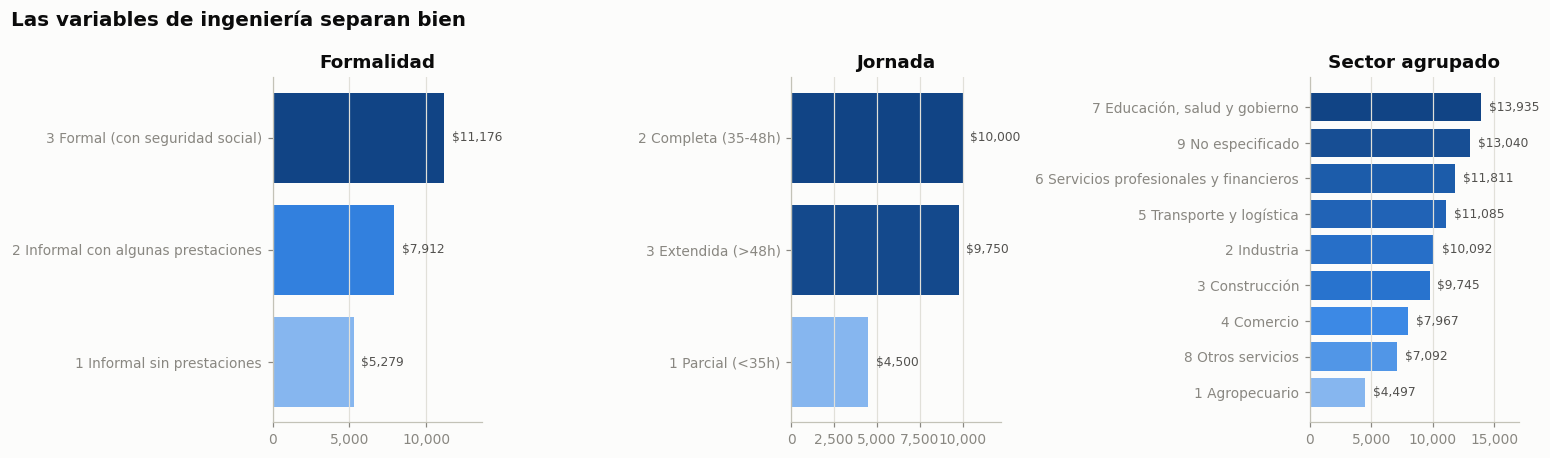

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
barras_categoria(axes[0], "formalidad", "Formalidad", segmento="Ocupados")
barras_categoria(axes[1], "jornada", "Jornada", segmento="Ocupados")
barras_categoria(axes[2], "sector_agrupado", "Sector agrupado", segmento="Ocupados")
fig.suptitle("Las variables de ingeniería separan bien", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "02_features_nuevas")

d = pd.DataFrame({"h": diag_ingreso_hora, "w": df["factor"], "f": df["formalidad"]}).dropna()
d = d[d["h"].between(1, wquantile(d["h"], .99, d["w"]))]
print("Diagnóstico (no es feature) — ingreso por hora mediano:")
display(pd.Series({k: wmedian(g["h"], g["w"]) for k, g in d.groupby("f")}).round(1))

---
## 8. Elicitability audit

This is the step that keeps the product honest. Every candidate is written as the **literal question a user
would answer**, and gets one of three verdicts:

- **Directa** — the person can answer it in one screen, from memory, without looking anything up.
- **Derivada** — not asked, but computable from answers that *are* asked (e.g. `experiencia_potencial`
  from age and schooling; `cve_entidad` from a location permission or a postcode).
- **No preguntable** — nobody can answer it about themselves in a form: household composition counts,
  dwelling materials, 1,112-way municipality pickers.

Notebook 03 ranks **only** the Directa and Derivada rows. A "No preguntable" column can still be excellent
statistically — `perceptores_hogar` is — and it is still out, because the model must run on what a user
actually types. This ordering, elicitability before importance, is the whole reason the form can be 15
questions instead of 45.


In [21]:
# (verdicto, pregunta que vería el usuario)
ELICITABILIDAD = {
    # --- Directa
    "edad": ("Directa", "¿Cuántos años tienes?"),
    "es_mujer": ("Directa", "¿Cuál es tu sexo?"),
    "anios_escolaridad": ("Directa", "¿Cuál es el último grado que aprobaste? (nivel + grado)"),
    "situacion_conyugal": ("Directa", "¿Cuál es tu situación conyugal?"),
    "habla_lengua_indigena": ("Directa", "¿Hablas alguna lengua indígena?"),
    "se_considera_indigena": ("Directa", "¿Te consideras indígena?"),
    "es_afrodescendiente": ("Directa", "¿Te consideras afrodescendiente?"),
    "tiene_discapacidad": ("Directa", "¿Tienes alguna discapacidad o dificultad severa?"),
    "lugar_nacimiento": ("Directa", "¿Naciste en el estado donde vives ahora?"),
    "es_jefe_hogar": ("Directa", "¿Eres la persona principal responsable de tu hogar?"),
    "tiene_trabajo_principal": ("Directa", "¿Trabajaste el mes pasado?  [ruteo entre los dos modelos]"),
    "tiene_trabajo_secundario": ("Directa", "¿Tienes un segundo trabajo?"),
    "n_trabajos": ("Directa", "¿Cuántos trabajos tienes?"),
    "posicion_ocupacion": ("Directa", "En tu trabajo, ¿eres empleado, patrón, trabajas por tu cuenta o sin pago?"),
    "sinco_grupo": ("Directa", "¿A cuál de estos 10 grupos se parece más tu ocupación?"),
    "sector_agrupado": ("Directa", "¿En qué sector trabajas? (8 opciones)"),
    "jornada": ("Directa", "¿Cuántas horas trabajas a la semana? (parcial / completa / más de 48)"),
    "horas_trabajadas": ("Directa", "¿Cuántas horas trabajaste la semana pasada?"),
    "formalidad": ("Directa", "¿Tu trabajo te da IMSS/ISSSTE y prestaciones?"),
    "tam_empresa_grupo": ("Directa", "¿Cuántas personas trabajan donde trabajas tú?"),
    "tiene_contrato_escrito": ("Directa", "¿Tienes contrato por escrito?"),
    "contrato_indefinido": ("Directa", "¿Tu contrato es por tiempo indefinido o temporal?"),
    "clase_empleador": ("Directa", "¿Trabajas para una empresa privada, el gobierno, u otro?"),
    "actividad_no_ocupado": ("Directa", "Si no trabajaste, ¿a qué te dedicaste? (jubilado, estudiante, hogar…)"),
    "tamanio_localidad": ("Directa", "¿Vives en una ciudad grande, una ciudad media, un pueblo o una zona rural?"),
    "asiste_a_escuela": ("Directa", "¿Estás estudiando actualmente?"),
    "integrantes_hogar": ("Directa", "¿Cuántas personas viven en tu hogar?"),
    "hijos_sobrevivientes": ("Directa", "¿Cuántos hijos tienes?"),
    # --- Derivada
    "cve_entidad": ("Derivada", "Estado de residencia — de la ubicación o del código postal"),
    "experiencia_potencial": ("Derivada", "edad − años de escolaridad − 6"),
    "es_migrante_interno": ("Derivada", "de 'lugar_nacimiento'"),
    "razon_dependencia": ("Derivada", "de tamaño del hogar y número de menores/adultos mayores"),
    "cotiza_seguridad_social": ("Derivada", "de 'formalidad'"),
    "empleo_formal": ("Derivada", "de 'formalidad'"),
    "n_prestaciones": ("Derivada", "de 'formalidad'; el conteo exacto nadie lo recuerda"),
    "sin_prestaciones": ("Derivada", "de 'formalidad'"),
    "tam_empresa": ("Derivada", "de 'tam_empresa_grupo'"),
    "scian_sector": ("Derivada", "de 'sector_agrupado'"),
    # --- No preguntable
    "cve_municipio": ("No preguntable", "1,112 municipios; además localiza demasiado al usuario"),
    "parentesco_grupo": ("No preguntable", "requiere describir el hogar completo"),
    "menores_hogar": ("No preguntable", "composición del hogar"),
    "adultos_mayores_hogar": ("No preguntable", "composición del hogar"),
    "ocupados_hogar": ("No preguntable", "composición del hogar"),
    "perceptores_hogar": ("No preguntable", "composición del hogar; además bordea el target"),
    "clase_hogar": ("No preguntable", "clasificación del censo, no del usuario"),
    "jefe_mujer": ("No preguntable", "sobre otra persona del hogar"),
    "edad_jefe": ("No preguntable", "sobre otra persona del hogar"),
    "educacion_jefe": ("No preguntable", "sobre otra persona del hogar"),
    "estrato_socioeconomico": ("No preguntable", "estrato de la manzana, asignado por INEGI"),
    "tipo_vivienda": ("No preguntable", "clasificación del entrevistador"),
    "material_piso": ("No preguntable", "nadie describe su piso en un formulario"),
    "num_cuartos": ("No preguntable", "friccional y poco creíble como autorreporte"),
    "num_dormitorios": ("No preguntable", "friccional y poco creíble como autorreporte"),
    "tenencia_vivienda": ("No preguntable", "posible, pero fricción alta para la señal que aporta"),
    "tiene_electricidad": ("No preguntable", "casi constante (99%)"),
    "drenaje_publico": ("No preguntable", "infraestructura, no autorreporte"),
    "agua_entubada_dentro": ("No preguntable", "infraestructura, no autorreporte"),
    "hacinamiento": ("No preguntable", "requiere contar cuartos"),
    "tiene_internet": ("No preguntable", "activo del hogar; correlaciona con el target por construcción"),
    "tiene_celular": ("No preguntable", "activo del hogar; casi constante"),
    "tiene_computadora": ("No preguntable", "activo del hogar"),
    "tiene_tarjeta_credito": ("No preguntable", "activo financiero; bordea el target"),
    "n_automoviles": ("No preguntable", "activo del hogar"),
    "sabe_leer_escribir": ("No preguntable", "implícito si está llenando un formulario"),
    "trabaja_en_mexico": ("No preguntable", "casi constante (99.7%)"),
    "tiene_socios": ("No preguntable", "83% de faltantes"),
    "tipo_actividad_negocio": ("No preguntable", "redundante con 'sector_agrupado'"),
    "n_dificultades": ("No preguntable", "se prefiere la binaria 'tiene_discapacidad'"),
}

TODAS = CANDIDATAS + NUEVAS
sin_auditar = [c for c in TODAS if c not in ELICITABILIDAD]
assert not sin_auditar, f"Candidatas sin auditar: {sin_auditar}"
sobran = [c for c in ELICITABILIDAD if c not in TODAS]
assert not sobran, f"Auditadas pero inexistentes: {sobran}"
print(f"{len(TODAS)} candidatas auditadas, ninguna pendiente")

68 candidatas auditadas, ninguna pendiente


In [22]:
senial_final = []
for c in TODAS:
    g = binificar(df[c])
    veredicto, pregunta = ELICITABILIDAD[c]
    senial_final.append({
        "variable": c,
        "veredicto": veredicto,
        "pregunta_al_usuario": pregunta,
        "tipo": "categórica" if es_categorica(df[c]) else "numérica",
        "n_niveles": int(df[c].nunique()),
        "pct_nulos_ocupados": round(df.loc[OCU, c].isna().mean() * 100, 1),
        "pct_nulos_no_ocup": round(df.loc[~OCU, c].isna().mean() * 100, 1),
        "eta2_ocupados": round(eta2_ponderado(g[OCU], LOG_ING[OCU], df.loc[OCU, "factor"]), 4),
        "eta2_no_ocupados": round(eta2_ponderado(g[~OCU], LOG_ING[~OCU], df.loc[~OCU, "factor"]), 4),
    })
candidatas = pd.DataFrame(senial_final)
orden = {"Directa": 0, "Derivada": 1, "No preguntable": 2}
candidatas = candidatas.sort_values(
    ["veredicto", "eta2_ocupados"], key=lambda s: s.map(orden) if s.name == "veredicto" else -s
).reset_index(drop=True)

print(candidatas["veredicto"].value_counts().to_string())
print(f"\nPool que entra a la selección de §03: "
      f"{(candidatas['veredicto'] != 'No preguntable').sum()} variables")
display(candidatas)

veredicto
No preguntable    30
Directa           28
Derivada          10

Pool que entra a la selección de §03: 38 variables


,variable,veredicto,pregunta_al_usuario,tipo,n_niveles,pct_nulos_ocupados,pct_nulos_no_ocup,eta2_ocupados,eta2_no_ocupados
0,sinco_grupo,Directa,¿A cuál de estos 10 grupos se parece más tu oc...,categórica,11,0.00,0.00,0.21,0.00
1,tiene_contrato_escrito,Directa,¿Tienes contrato por escrito?,numérica,2,24.90,100.00,0.19,0.00
2,formalidad,Directa,¿Tu trabajo te da IMSS/ISSSTE y prestaciones?,categórica,4,0.00,0.00,0.19,0.00
3,contrato_indefinido,Directa,¿Tu contrato es por tiempo indefinido o temporal?,numérica,2,62.80,100.00,0.19,0.00
4,horas_trabajadas,Directa,¿Cuántas horas trabajaste la semana pasada?,numérica,138,0.00,100.00,0.17,0.00
...,...,...,...,...,...,...,...,...,...
63,menores_hogar,No preguntable,composición del hogar,numérica,10,0.00,0.00,0.01,0.04
64,adultos_mayores_hogar,No preguntable,composición del hogar,numérica,6,0.00,0.00,0.00,0.04
65,trabaja_en_mexico,No preguntable,casi constante (99.7%),numérica,2,0.00,100.00,0.00,0.00
66,tiene_electricidad,No preguntable,casi constante (99%),numérica,2,0.00,0.00,0.00,0.00


Las 5 variables de mayor señal que el filtro descarta:


,variable,eta2_ocupados,pregunta_al_usuario
38,cve_municipio,0.19,"1,112 municipios; además localiza demasiado al..."
39,estrato_socioeconomico,0.14,"estrato de la manzana, asignado por INEGI"
40,educacion_jefe,0.14,sobre otra persona del hogar
41,tipo_actividad_negocio,0.11,redundante con 'sector_agrupado'
42,tiene_socios,0.10,83% de faltantes


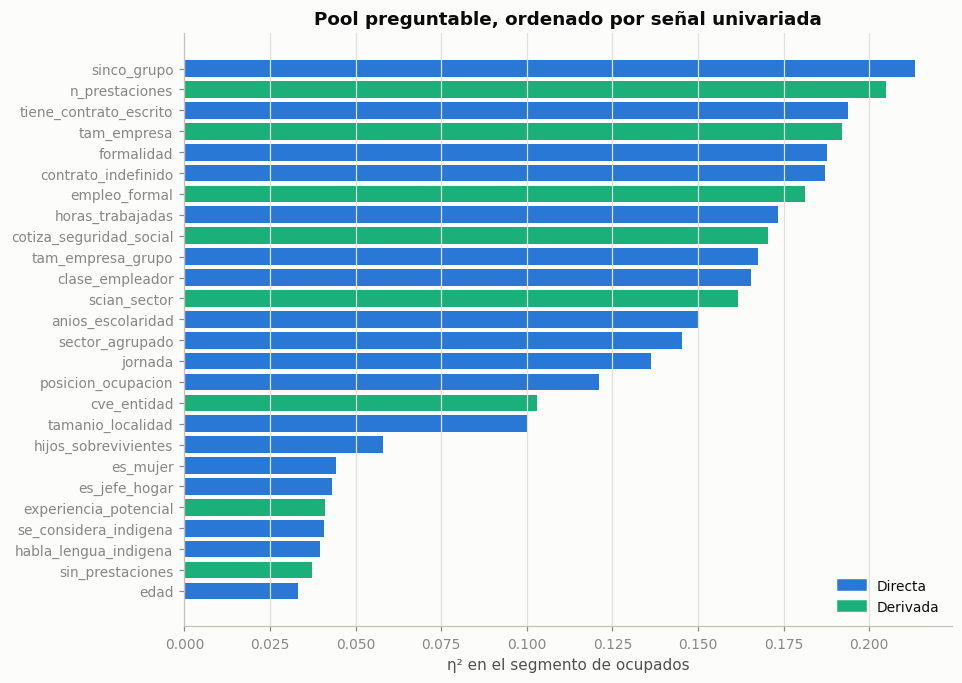

In [23]:
# ¿Cuánta señal deja fuera el filtro de elicitabilidad?
preguntables = candidatas[candidatas["veredicto"] != "No preguntable"]
fig, ax = plt.subplots(figsize=(9, 7))
t = preguntables.sort_values("eta2_ocupados").tail(26)
colores = [SERIES[0] if v == "Directa" else SERIES[2] for v in t["veredicto"]]
ax.barh(np.arange(len(t)), t["eta2_ocupados"], color=colores)
ax.set_yticks(np.arange(len(t))); ax.set_yticklabels(t["variable"])
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("η² en el segmento de ocupados")
ax.set_title("Pool preguntable, ordenado por señal univariada")
ax.legend(handles=[Patch(color=SERIES[0], label="Directa"),
                   Patch(color=SERIES[2], label="Derivada")], loc="lower right")
guardar(fig, "02_pool_preguntable")

perdidas = candidatas[candidatas["veredicto"] == "No preguntable"].nlargest(5, "eta2_ocupados")
print("Las 5 variables de mayor señal que el filtro descarta:")
display(perdidas[["variable", "eta2_ocupados", "pregunta_al_usuario"]])

---
## 9. Save

| File | Content |
|---|---|
| `enigh2024_features_v2.parquet` | every row, the target, the design variables, the surviving candidates and the 6 engineered features |
| `candidatas_v2.csv` | one row per candidate: verdict, user-facing question, type, levels, missingness, η² per segment |
| `eda_v2.json` | the de-duplication map and the column groups, so notebook 03 reads them instead of re-deriving them |
| `reports/figures/*.png` | the charts |


In [24]:
COLS_SALIDA = IDS + DISENIO + [TARGET, "segmento", "tiene_trabajo_principal"] + TODAS
COLS_SALIDA = list(dict.fromkeys(COLS_SALIDA))
salida = df[COLS_SALIDA].copy()

# Verificación de fuga: nada derivado del target puede viajar como candidata
PROHIBIDAS = set(FUGA) | {"ingreso_por_hora"}
fuga = PROHIBIDAS & set(TODAS)
assert not fuga, f"FUGA: {fuga} está en la lista de candidatas"
assert TARGET not in TODAS
print("Verificación de fuga: OK — ninguna candidata deriva del target")

# Invariante de tipado: una categórica mal tipada sale de aquí como columna vacía.
vacias = [c for c in TODAS if salida[c].isna().all()]
assert not vacias, f"Candidatas completamente vacías (revisar tipado): {vacias}"
print(f"Verificación de tipado: OK — {sum(es_categorica(salida[c]) for c in TODAS)} categóricas "
      f"y {sum(es_numerica(salida[c]) for c in TODAS)} numéricas, ninguna vacía")

ruta_parquet = PROC_DIR / "enigh2024_features_v2.parquet"
ruta_cand = PROC_DIR / "candidatas_v2.csv"
ruta_meta = PROC_DIR / "eda_v2.json"

salida.to_parquet(ruta_parquet, index=False)
candidatas.to_csv(ruta_cand, index=False, encoding="utf-8")

meta = {
    "origen": "02_eda_feature_engineering.ipynb",
    "entrada": "enigh2024_ingreso_personas.parquet",
    "filas": int(len(salida)),
    "target": TARGET,
    "tratamiento_target": "log(ingreso) con objetivo cuantil/L1; la predicción puntual es la MEDIANA "
                          "condicional, retransformada con exp() y sin smearing",
    "metricas_cabecera": ["MdAPE", "% dentro de ±20%", "cobertura del intervalo [q10,q90]"],
    "segmentos": {"ruteo": "tiene_trabajo_principal",
                  "ocupados": int(OCU.sum()), "no_ocupados": int((~OCU).sum())},
    "columnas": {"target_y_componentes": FUGA, "identificadores": IDS, "diseno_muestral": DISENIO,
                 "duplicadas_descartadas": DESCARTADAS_DUP,
                 "candidatas": TODAS, "nuevas": NUEVAS},
    "duplicados": [{"conserva": k, "descarta": ds, "motivo": m} for k, ds, m in DUPLICADOS],
    "pool_preguntable": preguntables["variable"].tolist(),
    "siguiente_paso": "03_feature_selection.ipynb — split por upm, selección sobre train, curva "
                      "desempeño vs k, congelar ~15 features por segmento",
}
ruta_meta.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

for r in (ruta_parquet, ruta_cand, ruta_meta):
    print(f"OK  {r.name}  ({r.stat().st_size / 1e6:.2f} MB)")
print(f"OK  {len(list(FIG_DIR.glob('02_*.png')))} figuras en reports/figures/")

Verificación de fuga: OK — ninguna candidata deriva del target
Verificación de tipado: OK — 22 categóricas y 46 numéricas, ninguna vacía


OK  enigh2024_features_v2.parquet  (5.24 MB)
OK  candidatas_v2.csv  (0.01 MB)
OK  eda_v2.json  (0.01 MB)
OK  11 figuras en reports/figures/


In [25]:
print(f"93 columnas de entrada")
print(f"  → {len(CANDIDATAS)} candidatas tras quitar target, identificadores, diseño y duplicadas")
print(f"  → +{len(NUEVAS)} variables de ingeniería  =  {len(TODAS)} auditadas")
print(f"  → {len(preguntables)} preguntables, que son las que entran a la selección de §03")
print(f"  → objetivo de formulario: ~15 por modelo")

93 columnas de entrada
  → 62 candidatas tras quitar target, identificadores, diseño y duplicadas
  → +6 variables de ingeniería  =  68 auditadas
  → 38 preguntables, que son las que entran a la selección de §03
  → objetivo de formulario: ~15 por modelo


---
## Summary

93 input columns → candidates after removing the target, the identifiers, the design variables and the
duplicate encodings → of those, the ones a person can actually answer, plus 6 engineered features that turn
several raw columns into single questions. The exact counts are printed above.

Nothing has been selected and nothing has been fitted. Notebook 03 takes `candidatas_v2.csv`, owns the
`upm`-grouped split, and does the ranking on the training partition only.

**Open questions for §03**

1. `horas_trabajadas` vs `jornada` — the raw number carries more signal, the band is easier to ask.
   Let the selection curve decide, per segment.
2. `cve_entidad` (32 levels) is Derivada and strong. If the app cannot get location, the fallback is
   `tamanio_localidad`, which costs real accuracy — worth measuring explicitly.
3. The non-worker model leans heavily on `actividad_no_ocupado`. Check that its categories are stable
   enough to expose as a user-facing question.
